# Evaluation & Model Comparison — Group Notebook
## WELFake Dataset — NLP_Group_04

**This is the group's official model comparison notebook**, superseding any individual evaluation attempts. It consolidates results from all three members' individually trained models (6 models total: 3 ML + 3 DL) to identify the best-performing ML model and best-performing DL model for the Final Integrated Application.

**Group Members:**
- Pulindu Pasanjith (CIT-24-01-0011) — Logistic Regression, LSTM
- Irusha Madushan (CIT-24-01-0514) — Random Forest, CNN
- Matheesha Desaman (CIT-24-01-0435) — Naive Bayes, BERT Fine-tuning

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")

✅ Libraries imported!


## 1. Load and Standardise All Member Results

Each member saved their results in a slightly different JSON format.
This section normalises all three into one consistent structure for fair comparison.

In [2]:
def load_results():
    with open('../reports/pulindu_results.json') as f:
        pulindu = json.load(f)
    with open('../reports/irusha_results.json') as f:
        irusha = json.load(f)
    with open('../reports/matheesha_results.json') as f:
        matheesha = json.load(f)

    standardized = []

    # Pulindu — Logistic Regression + LSTM
    for model_name, metrics in pulindu['models'].items():
        standardized.append({
            "member_id": pulindu['student_id'],
            "member_name": pulindu['member'],
            "model_name": model_name,
            "model_type": "ML" if model_name == "Logistic Regression" else "DL",
            "feature_method": "TF-IDF" if model_name == "Logistic Regression" else "Tokenised Sequences",
            "accuracy": metrics['accuracy'],
            "precision": metrics['precision'],
            "recall": metrics['recall'],
            "f1_score": metrics['f1_score'],
            "roc_auc": None
        })

    # Irusha — Random Forest + CNN
    for m in irusha['models']:
        is_ml = "Random Forest" in m['model_name']
        standardized.append({
            "member_id": irusha['member_id'],
            "member_name": irusha['member_name'],
            "model_name": m['model_name'],
            "model_type": "ML" if is_ml else "DL",
            "feature_method": "TF-IDF" if is_ml else "Word2Vec",
            "accuracy": m['accuracy'],
            "precision": m['precision'],
            "recall": m['recall'],
            "f1_score": m['f1_score'],
            "roc_auc": None
        })

    # Matheesha — Naive Bayes + BERT
    for key, is_ml in [('ml_model', True), ('dl_model', False)]:
        m = matheesha[key]
        standardized.append({
            "member_id": matheesha['member_id'],
            "member_name": matheesha['member_name'],
            "model_name": m['model_name'],
            "model_type": "ML" if is_ml else "DL",
            "feature_method": m['feature_method'],
            "accuracy": m['accuracy'],
            "precision": m['precision'],
            "recall": m['recall'],
            "f1_score": m['f1_score'],
            "roc_auc": m.get('roc_auc')
        })

    return pd.DataFrame(standardized)

results_df = load_results()
results_df

,member_id,member_name,model_name,model_type,feature_method,accuracy,precision,recall,f1_score,roc_auc
0,CIT-24-01-0011,Pulindu Pasanjith,Logistic Regression,ML,TF-IDF,0.957943,0.953557,0.965149,0.959318,NaN
1,CIT-24-01-0011,Pulindu Pasanjith,LSTM,DL,Tokenised Sequences,0.939690,0.944732,0.937458,0.941081,NaN
2,CIT-24-01-0514,W.A. Irusha Madushan,Random Forest (TF-IDF),ML,TF-IDF,0.955300,0.948900,0.965000,0.956900,NaN
3,CIT-24-01-0514,W.A. Irusha Madushan,CNN (Word2Vec Embeddings),DL,Word2Vec,0.967900,0.957300,0.981400,0.969200,NaN
4,CIT-24-01-0435,Matheesha Desaman,Naive Bayes (GaussianNB),ML,BERT Embeddings,0.807500,0.783500,0.870200,0.824600,0.8619
5,CIT-24-01-0435,Matheesha Desaman,BERT Fine-tuning,DL,BERT Embeddings,0.950000,0.950000,0.950000,0.952500,NaN


## 2. Full Comparison Table

All 6 models side by side, ranked by F1-Score.

In [3]:
comparison_table = results_df[['member_name', 'model_name', 'model_type',
                                'feature_method', 'accuracy', 'precision',
                                'recall', 'f1_score']].sort_values('f1_score', ascending=False)

comparison_table = comparison_table.round(4)
comparison_table.reset_index(drop=True, inplace=True)
comparison_table

,member_name,model_name,model_type,feature_method,accuracy,precision,recall,f1_score
0,W.A. Irusha Madushan,CNN (Word2Vec Embeddings),DL,Word2Vec,0.9679,0.9573,0.9814,0.9692
1,Pulindu Pasanjith,Logistic Regression,ML,TF-IDF,0.9579,0.9536,0.9651,0.9593
2,W.A. Irusha Madushan,Random Forest (TF-IDF),ML,TF-IDF,0.9553,0.9489,0.9650,0.9569
3,Matheesha Desaman,BERT Fine-tuning,DL,BERT Embeddings,0.9500,0.9500,0.9500,0.9525
4,Pulindu Pasanjith,LSTM,DL,Tokenised Sequences,0.9397,0.9447,0.9375,0.9411
5,Matheesha Desaman,Naive Bayes (GaussianNB),ML,BERT Embeddings,0.8075,0.7835,0.8702,0.8246


In [4]:
comparison_table.to_csv('../reports/final_model_comparison.csv', index=False)
print("✅ Comparison table saved to reports/final_model_comparison.csv")

✅ Comparison table saved to reports/final_model_comparison.csv


## 3. Visual Comparison

Bar charts comparing all 6 models across accuracy, precision, recall, and F1-score.

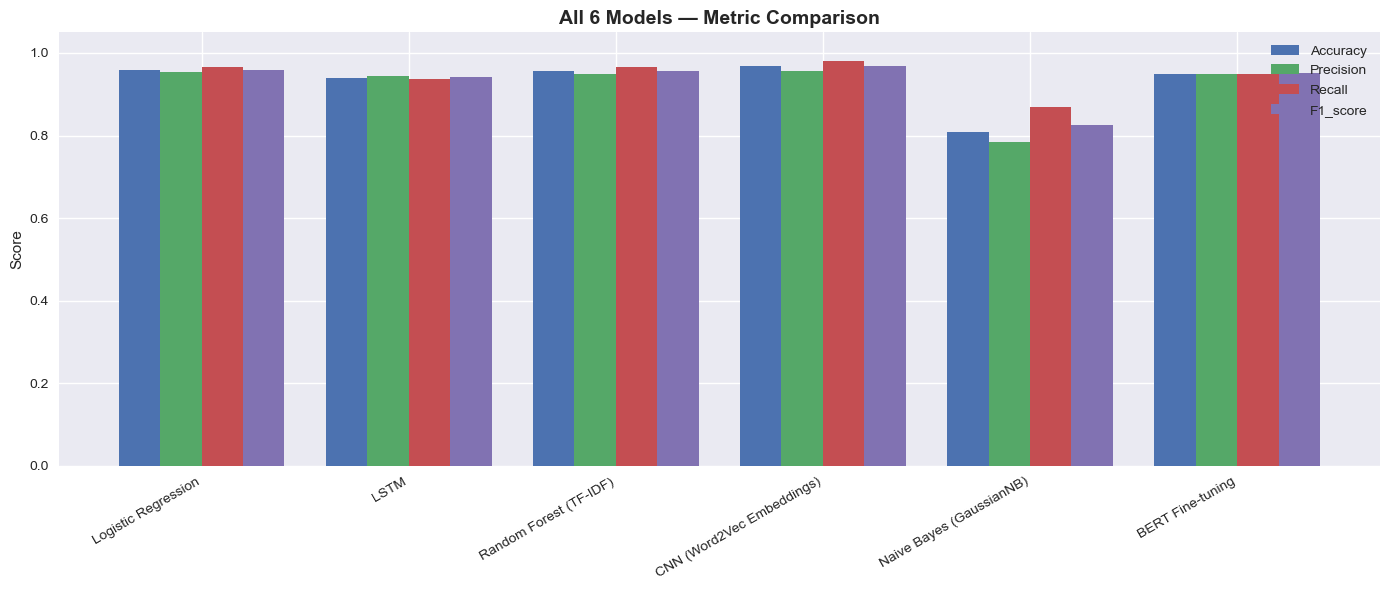

In [5]:
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric.capitalize())

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df['model_name'], rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('All 6 Models — Metric Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../screenshots/10_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

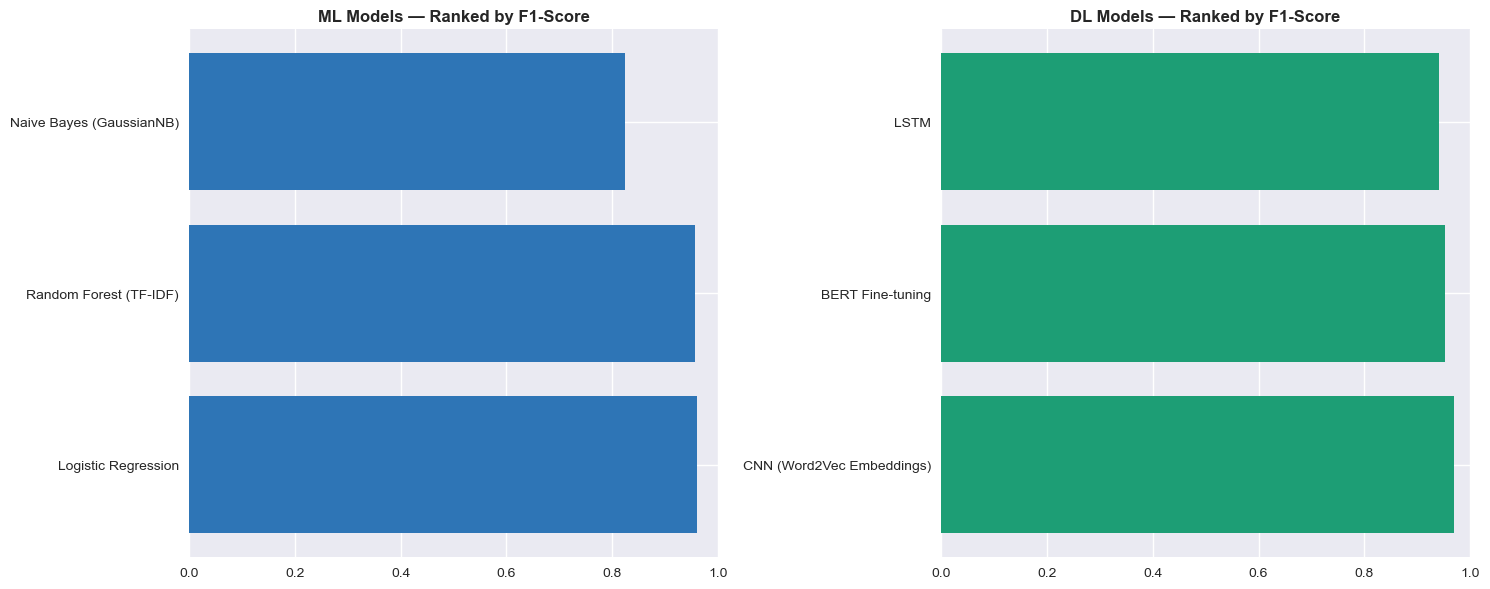

Best ML model: Logistic Regression (F1: 0.9593)
Best DL model: CNN (Word2Vec Embeddings) (F1: 0.9692)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ml_df = results_df[results_df['model_type'] == 'ML'].sort_values('f1_score', ascending=False)
dl_df = results_df[results_df['model_type'] == 'DL'].sort_values('f1_score', ascending=False)

axes[0].barh(ml_df['model_name'], ml_df['f1_score'], color='#2E75B6')
axes[0].set_title('ML Models — Ranked by F1-Score', fontweight='bold')
axes[0].set_xlim(0, 1)

axes[1].barh(dl_df['model_name'], dl_df['f1_score'], color='#1D9E75')
axes[1].set_title('DL Models — Ranked by F1-Score', fontweight='bold')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('../screenshots/11_ml_vs_dl_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print("Best ML model:", ml_df.iloc[0]['model_name'], f"(F1: {ml_df.iloc[0]['f1_score']:.4f})")
print("Best DL model:", dl_df.iloc[0]['model_name'], f"(F1: {dl_df.iloc[0]['f1_score']:.4f})")